In [1]:
from pathlib import Path
import sys

ROOT_DIR = Path.cwd().parent.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
print(f'Base directory -> {ROOT_DIR}')

from src.db_conn import DatabaseConnection
from config.settings import (
    DATA_DIR
)

import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

Base directory -> /Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/paramiko/pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/paramiko/transport.py:253: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
master = pd.read_csv(f'{DATA_DIR}/master.csv')

display(master)

,sale_date,net_price,non_work_day,is_month_end,close_month_zone
0,2024-01-02,"719,422.63",0,0,0
1,2024-01-03,"992,292.59",0,0,0
2,2024-01-04,"802,011.48",0,0,0
3,2024-01-05,"484,853.02",0,0,0
4,2024-01-06,"60,058.17",0,0,0
...,...,...,...,...,...
860,2026-05-11,"1,790,415.58",0,0,0
861,2026-05-12,"2,139,962.69",0,0,0
862,2026-05-13,"1,245,428.49",0,0,1
863,2026-05-14,"1,656,746.25",0,0,1


In [3]:
#definimos train, test, validation
train_cutoff = '2026-03-31'
validation_start = '2026-04-01'
validation_end = '2026-04-30'

In [4]:
#seoaramos la variable target de las exogenas
y = master['net_price']
X = master[['non_work_day', 'is_month_end', 'close_month_zone']]

display(X)
display(y)

,non_work_day,is_month_end,close_month_zone
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
860,0,0,0
861,0,0,0
862,0,0,1
863,0,0,1


0       719,422.63
1       992,292.59
2       802,011.48
3       484,853.02
4        60,058.17
          ...     
860   1,790,415.58
861   2,139,962.69
862   1,245,428.49
863   1,656,746.25
864     646,434.79
Name: net_price, Length: 865, dtype: float64

In [5]:
y.index = pd.to_datetime(master['sale_date'])
X.index = pd.to_datetime(master['sale_date'])
#split de datos
y_train = y[:train_cutoff]
y_val   = y[validation_start:validation_end]

X_train = X[:train_cutoff]
X_val   = X[validation_start:validation_end]

display(X_train)
display(y_train)

,non_work_day,is_month_end,close_month_zone
sale_date,,,
2024-01-02,0,0,0
2024-01-03,0,0,0
2024-01-04,0,0,0
2024-01-05,0,0,0
2024-01-06,0,0,0
...,...,...,...
2026-03-27,0,0,1
2026-03-28,0,0,0
2026-03-29,0,0,0


sale_date
2024-01-02     719,422.63
2024-01-03     992,292.59
2024-01-04     802,011.48
2024-01-05     484,853.02
2024-01-06      60,058.17
                 ...     
2026-03-27   1,237,289.26
2026-03-28           0.00
2026-03-29           0.00
2026-03-30   2,718,817.07
2026-03-31   2,964,747.97
Name: net_price, Length: 820, dtype: float64

In [6]:
df_prophet_train = pd.DataFrame({
    'ds': y_train.index,
    'y': y_train.values,
    'is_month_end': X_train['is_month_end'].values,
    'close_month_zone': X_train['close_month_zone'].values
})

display(df_prophet_train)


,ds,y,is_month_end,close_month_zone
0,2024-01-02,"719,422.63",0,0
1,2024-01-03,"992,292.59",0,0
2,2024-01-04,"802,011.48",0,0
3,2024-01-05,"484,853.02",0,0
4,2024-01-06,"60,058.17",0,0
...,...,...,...,...
815,2026-03-27,"1,237,289.26",0,1
816,2026-03-28,0.00,0,0
817,2026-03-29,0.00,0,0
818,2026-03-30,"2,718,817.07",0,1


In [7]:
p = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True, 
    daily_seasonality=False,
    interval_width=0.95
)

p.add_regressor('is_month_end')
p.add_regressor('close_month_zone')

p.fit(df_prophet_train)

06:46:46 - cmdstanpy - INFO - Chain [1] start processing
06:46:47 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
fechas_futuras = pd.date_range(start="2026-04-01", end="2026-04-30", freq='D')
df_exog_futuro = pd.DataFrame(index=fechas_futuras)

feriados_urvet_2026 = ['2026-04-02', '2026-04-03', '2026-05-01']
df_exog_futuro['non_work_day'] = df_exog_futuro.index.strftime('%Y-%m-%d').isin(feriados_urvet_2026).astype(int)

is_weekend = df_exog_futuro.index.weekday.isin([5, 6])
df_exog_futuro['is_workday'] = ~(is_weekend | (df_exog_futuro['non_work_day'] == 1))

df_exog_futuro['is_month_end'] = 0
df_exog_futuro['close_month_zone'] = 0

for period, group in df_exog_futuro.groupby(df_exog_futuro.index.to_period('M')):
    work_days_month = group[group['is_workday']].index
    
    if len(work_days_month) >= 1:
        df_exog_futuro.loc[work_days_month[-1], 'is_month_end'] = 1
        
    if len(work_days_month) >= 3:
        df_exog_futuro.loc[work_days_month[-3:-1], 'close_month_zone'] = 1
    elif len(work_days_month) == 2:
        df_exog_futuro.loc[work_days_month[0], 'close_month_zone'] = 1


df_prophet_futuro = df_exog_futuro.reset_index().rename(columns={'index': 'ds'})
df_prophet_futuro = df_prophet_futuro[['ds', 'is_month_end', 'close_month_zone']]


forecast_prophet = p.predict(df_prophet_futuro)

predicciones_limpias = forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

print("DataFrame exógeno generado desde cero. Vista previa de predicciones:")
display(predicciones_limpias)

DataFrame exógeno generado desde cero. Vista previa de predicciones:


,ds,yhat,yhat_lower,yhat_upper
0,2026-04-01,"1,230,871.42","401,932.59","2,068,601.21"
1,2026-04-02,"1,325,567.25","558,354.79","2,093,675.78"
2,2026-04-03,"1,288,943.24","448,583.24","2,140,725.73"
3,2026-04-04,"334,473.67","-487,742.24","1,199,673.29"
4,2026-04-05,"294,553.68","-517,034.52","1,143,723.89"
5,2026-04-06,"1,501,716.76","677,850.23","2,348,685.73"
6,2026-04-07,"1,547,587.53","672,237.79","2,365,051.46"
7,2026-04-08,"1,234,051.55","395,989.79","2,094,043.63"
8,2026-04-09,"1,328,747.38","483,857.25","2,128,530.29"
9,2026-04-10,"1,292,123.37","494,346.88","2,089,238.44"


In [12]:
real_array = np.array(y_val).flatten()
pred_array = np.array(predicciones_limpias['yhat']).flatten()

error = np.abs(real_array - pred_array)

wape_puro = (np.sum(np.abs(real_array - pred_array)) / np.sum(real_array)) * 100

diferencia_total_porcentual = ((pred_array.sum() - real_array.sum()) / real_array.sum()) * 100

print(f"Suma real total abril: {real_array.sum():,.2f}")
print(f"Suma pred total abril: {pred_array.sum():,.2f}")
print(f'Error acumulado abril: {error.sum()}')
print(f'diff real: {real_array.sum()-pred_array.sum():,.2f}')


print(f"Diff total porcentual mensual: {diferencia_total_porcentual:.2f}%")
print(f"WMAPE total abril: {wape_puro:.2f}%")



Suma real total abril: 34,292,377.81
Suma pred total abril: 34,973,405.17
Error acumulado abril: 11999998.14620798
diff real: -681,027.36
Diff total porcentual mensual: 1.99%
WMAPE total abril: 34.99%


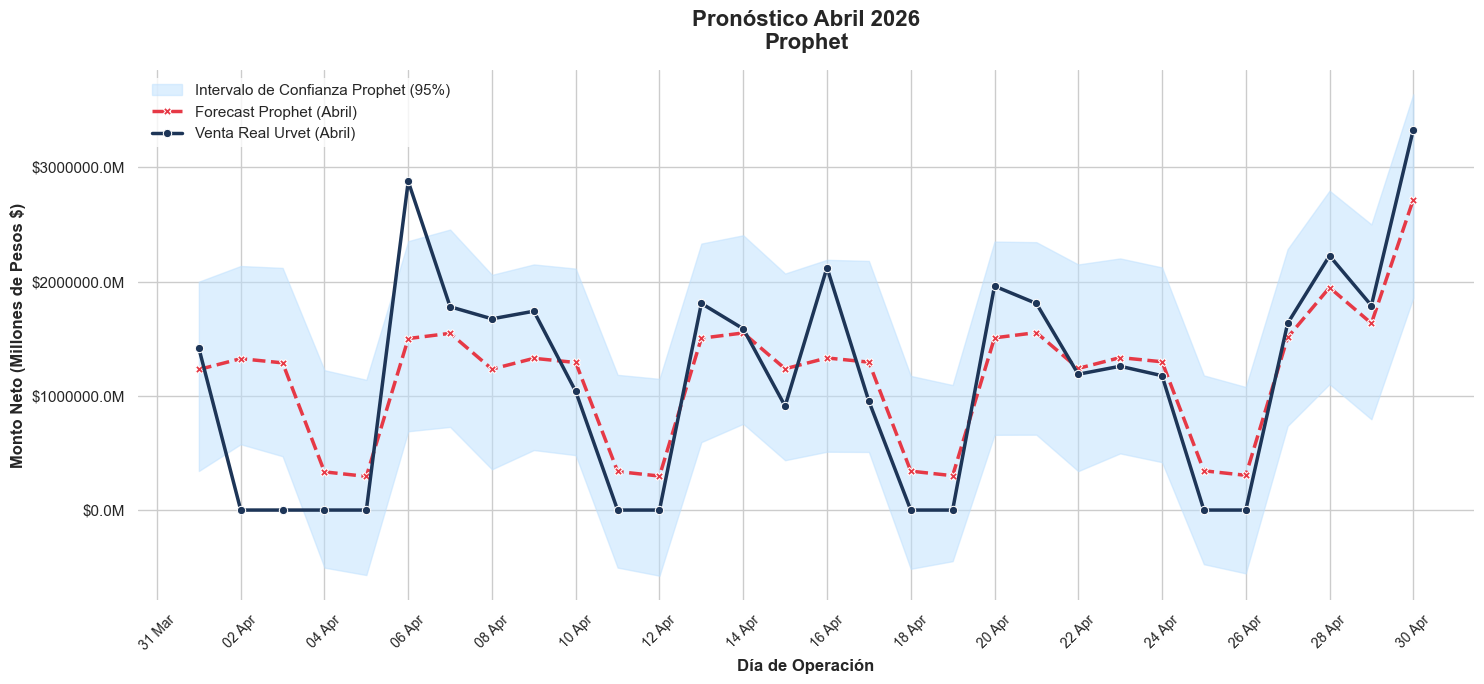

In [9]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 7), dpi=100)

forecast_prophet['ds'] = pd.to_datetime(forecast_prophet['ds'])

mask_abril = (forecast_prophet['ds'] >= '2026-04-01') & (forecast_prophet['ds'] <= '2026-04-30')
forecast_abril = forecast_prophet[mask_abril]

plt.fill_between(
    forecast_abril['ds'], 
    forecast_abril['yhat_lower'], 
    forecast_abril['yhat_upper'], 
    color='#bde0fe', 
    alpha=0.5, 
    label='Intervalo de Confianza Prophet (95%)'
)

sns.lineplot(
    x=forecast_abril['ds'], 
    y=forecast_abril['yhat'], 
    marker='X', 
    markersize=6,
    color='#e63946', 
    linewidth=2.5, 
    linestyle='--', 
    label='Forecast Prophet (Abril)'
)

y_real_eval = y['2026-04-01':'2026-04-30'] 

sns.lineplot(
    x=y_real_eval.index, 
    y=y_real_eval.values, 
    marker='o', 
    markersize=6,
    color='#1d3557', 
    linewidth=2.5, 
    label='Venta Real Urvet (Abril)'
)

plt.title('Pronóstico Abril 2026\nProphet', 
          fontsize=16, fontweight='bold', pad=15, family='Arial')
plt.ylabel('Monto Neto (Millones de Pesos $)', fontsize=12, fontweight='bold')
plt.xlabel('Día de Operación', fontsize=12, fontweight='bold')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45, fontsize=10)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:.1f}M"))

plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', fontsize=11)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()